In [5]:
#Steam平台29年增长曲线可视化 (1997–2025)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

df = pd.read_csv(r'D:\Python-Learn\steam-gamedataset/data storage/01-platform-evolution/01_temporal_growth.csv',
                 skipinitialspace=True
                 ).dropna(subset=['release_year']) #去掉末尾空行

#年份转整数
df['release_year'] = df['release_year'].astype(int)

print('总记录数',len(df))
print('字段数量',df.columns)
df.head(5)

总记录数 29
字段数量 Index(['release_year', 'apps_released', 'games_released', 'dlc_released',
       'free_apps', 'avg_price_usd'],
      dtype='object')


,release_year,apps_released,games_released,dlc_released,free_apps,avg_price_usd
0,1997,2,2,0,1,9.99
1,1998,1,1,0,0,9.99
2,1999,2,2,0,0,4.99
3,2000,2,2,0,0,7.49
4,2001,4,4,0,0,12.49


In [6]:
#免费游戏占比
df['free_pct'] = (df['free_apps'] / df['games_released'] * 100).round(1)

print(f"数据范围: {df['release_year'].min()} – {df['release_year'].max()}")
print(f"共计 {len(df)} 年")
df.head(5)

数据范围: 1997 – 2025
共计 29 年


,release_year,apps_released,games_released,dlc_released,free_apps,avg_price_usd,free_pct
0,1997,2,2,0,1,9.99,50.0
1,1998,1,1,0,0,9.99,0.0
2,1999,2,2,0,0,4.99,0.0
3,2000,2,2,0,0,7.49,0.0
4,2001,4,4,0,0,12.49,0.0


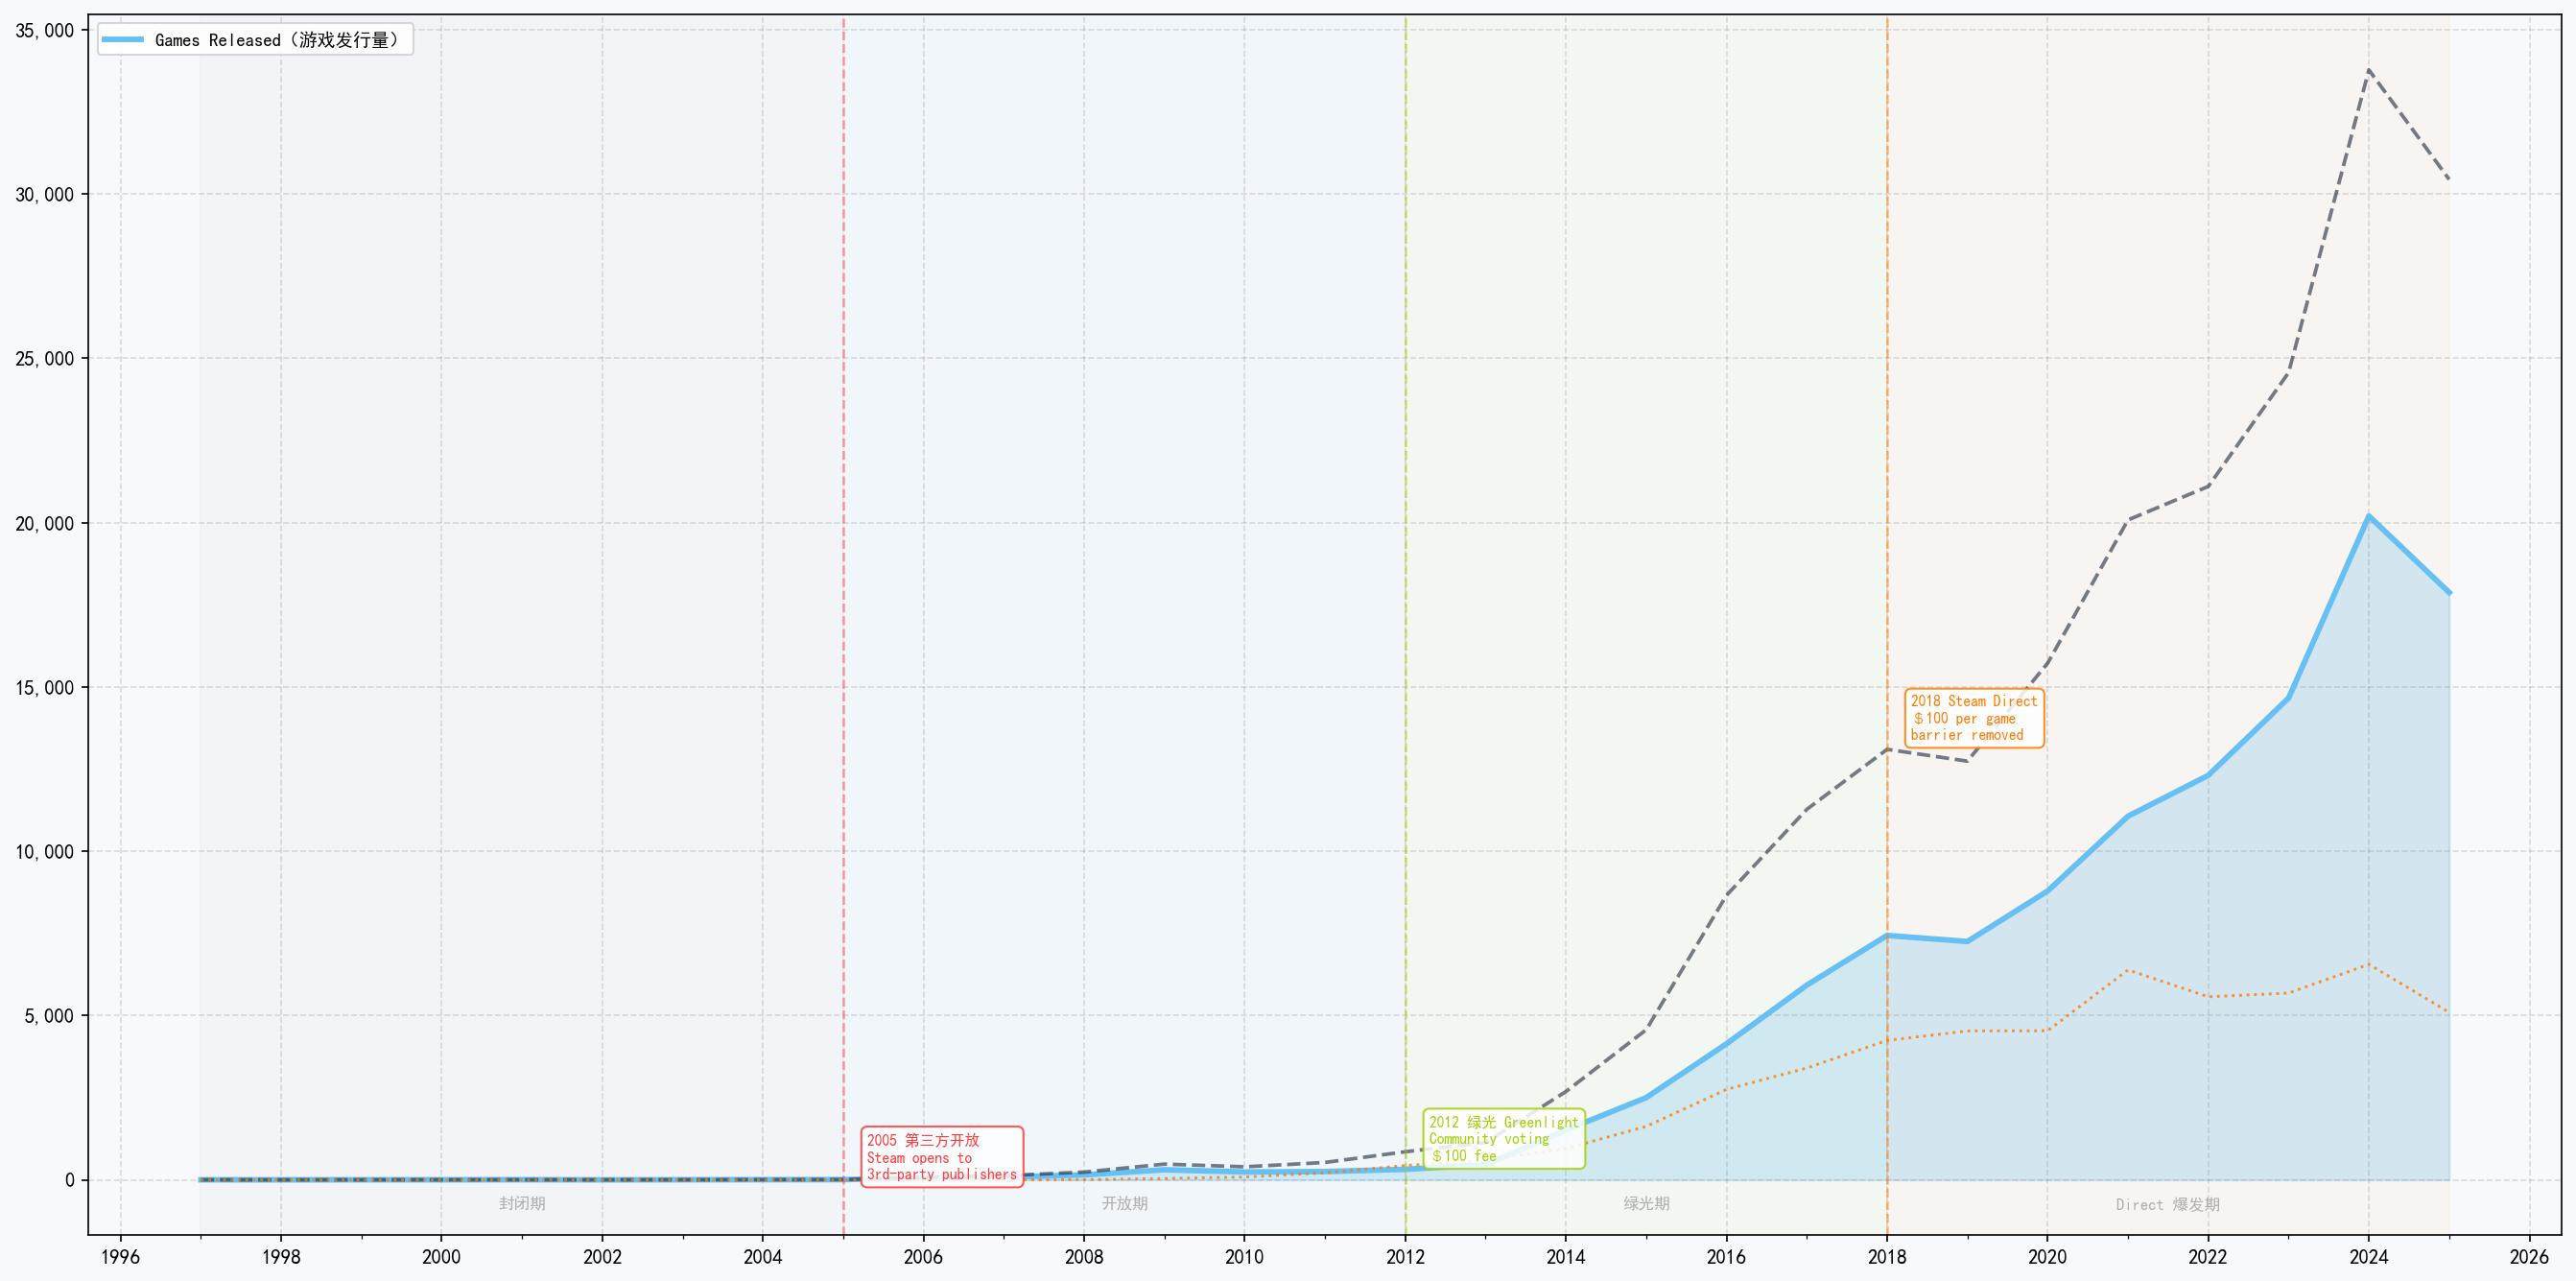

静态图已保存为 steam_growth.png


In [7]:
#自行查阅获得的steam官方配色
STEAM_DARK  = '#1b2838'
STEAM_BLUE  = '#66c0f4'
STEAM_GREEN = '#a4d007'
STEAM_ORANGE = '#ff7b00'
STEAM_RED   = '#ff3b3b'
BG_COLOR    = '#f7f9fc'

fig, ax = plt.subplots(figsize=(18, 9))
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

years = df['release_year'].values
games = df['games_released'].values
apps  = df['apps_released'].values
dlc   = df['dlc_released'].values

# 主要指标 游戏发行量-背景填充+实线
ax.fill_between(years, 0, games, alpha=0.25, color=STEAM_BLUE, label='_nolegend_')
ax.plot(years, games, color=STEAM_BLUE, linewidth=2.8, label='Games Released（游戏发行量）')

# 次要指标 应用总发行量-虚线
ax.plot(years, apps, color=STEAM_DARK, linewidth=1.8, linestyle='--', alpha=0.6)

# 辅助指标 Dlc发行量-点线
ax.plot(years, dlc, color=STEAM_ORANGE, linewidth=1.4, linestyle=':', alpha=0.8)

# 取自公开资料
Important_Point =[
    {
        'year': 2005,
        'y': 7,
        'title': '2005 第三方开放',
        'sub':  'Steam opens to\n3rd-party publishers',
        'ha':   'left',
        'xoff':  0.3,
    },
    {
        'year': 2012,
        'y': 320,
        'title': '2012 绿光 Greenlight',
        'sub':  'Community voting\n＄100 fee',
        'ha':   'left',
        'xoff':  0.3,
    },
    {
        'year': 2018,
        'y': 7438,
        'title': '2018 Steam Direct',
        'sub':  '＄100 per game\nbarrier removed',
        'ha':   'left',
        'xoff':  0.3,
    }
]

for i, m in enumerate(Important_Point):
    color = [STEAM_RED, STEAM_GREEN, STEAM_ORANGE][i]
    # 竖虚线
    ax.axvline(x=m['year'], color=color, linewidth=1.2, linestyle='--', alpha=0.5)
    # 浮动文字框
    ax.annotate(
    f"{m['title']}\n{m['sub']}",
    xy=(m['year'], m['y']),
    xytext=(m['year'] + m['xoff'], m['y'] * 1.8),
    fontsize=7.5,
    color=color,
    fontweight='bold',
    ha=m['ha'],
    linespacing=1.3,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=color, alpha=0.85),
)

#X轴每2年一个刻度
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))

#Y轴千分位
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

#网格用浅灰色虚线，半透明
ax.grid(True, linestyle='--', alpha=0.25, color='gray')

ax.legend(loc='upper left', fontsize=9, framealpha=0.9, edgecolor='lightgray')

"""
2005 年开放第三方
2012 年推出绿光,本身是一款“征集社区帮助,挑选新游戏在Steam上发布的系统”，中文社区正式名称为青睐之光
2018 年推出 Direct，替代了绿光
将这三个节点作为里程碑，并以此划分不同发展阶段
"""

for start, end, label in [
    (1997, 2005, '封闭期'),
    (2005, 2012, '开放期'),
    (2012, 2018, '绿光期'),
    (2018, 2025, 'Direct 爆发期'),
]:
    ax.axvspan(start, end, alpha=0.04, color=['gray', STEAM_BLUE, STEAM_GREEN, STEAM_ORANGE][
        ['封闭期','开放期','绿光期','Direct 爆发期'].index(label)
    ])
    ax.text((start + end) / 2, -900, label, ha='center', fontsize=8,color='gray', fontweight='bold', alpha=0.6)

plt.tight_layout()
plt.savefig(r'D:\Python-Learn\steam-gamedataset\png\steam_growth.png', dpi=300, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print("静态图已保存为 steam_growth.png")

# 待添加交互能力

In [11]:
#  Plotly交互
fig_ply = make_subplots(specs=[[{"secondary_y": False}]])

# 面积 + 线: 游戏发行量
fig_ply.add_trace(go.Scatter(
    x=df['release_year'], y=df['games_released'],
    mode='lines+markers',
    name='🎮 Games Released',
    line=dict(color=STEAM_BLUE, width=3),
    fill='tozeroy',
    fillcolor='rgba(102,192,244,0.2)',
    hovertemplate='%{x}<br>Games: <b>%{y:,}</b><extra></extra>',
))

# 虚线: 应用总量
fig_ply.add_trace(go.Scatter(
    x=df['release_year'], y=df['apps_released'],
    mode='lines',
    name='📦 Apps Released',
    line=dict(color=STEAM_DARK, width=1.5, dash='dash'),
    hovertemplate='%{x}<br>Apps: <b>%{y:,}</b><extra></extra>',
))

# 点线: DLC
fig_ply.add_trace(go.Scatter(
    x=df['release_year'], y=df['dlc_released'],
    mode='lines',
    name='📥 DLC Released',
    line=dict(color=STEAM_ORANGE, width=1.2, dash='dot'),
    hovertemplate='%{x}<br>DLC: <b>%{y:,}</b><extra></extra>',
))

# 三条里程碑竖线
for yr, color, name in [
    (2005, STEAM_RED, '2005 第三方开放'),
    (2012, STEAM_GREEN, '2012 绿光 Greenlight'),
    (2018, STEAM_ORANGE, '2018 Steam Direct'),
]:
    fig_ply.add_vline(x=yr, line_width=1.5, line_dash='dash', line_color=color,
                        annotation_text=name, annotation_position='top left',
                        annotation_font_size=11, annotation_font_color=color)

fig_ply.update_layout(
    title=dict(
        text='<b>Steam 28-Year Growth</b> · 1997 → 2025',
        font=dict(size=20, color=STEAM_DARK),
    ),
    xaxis=dict(title='Year', tickmode='linear', dtick=2, range=[1996.5, 2025.5]),
    yaxis=dict(title='Number of Releases', tickformat=','),
    template='plotly_white',
    hovermode='x unified',
    height=600,
    legend=dict(orientation='h', y=1.12, x=0.5, xanchor='center'),
)

fig_ply.show()
print("交互图已渲染")
fig_ply.write_html(r'D:\Python-Learn\steam-gamedataset\png\Plotly_steam_growth.html')

交互图已渲染
